# Carbon Stock RF — exp_carbon_stock

###### 1a: 1m stock, all tiers (3,700) R²=0.195
###### 1b: 1m stock, Tier 1+2 (700) R²=0.306
###### 2a: Full profile stock, all tiers (1,600) R²=0.327
###### 2b: Full profile stock, Tier 1+2 (300) R²=0.312


In [2]:
# Cell 1 — Imports and paths
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

ID      = 'DNR Peat Inventory ID #'
BASE_M  = '/scratch.global/ocon0444/peat_modeling'
BASE_I  = '/scratch.global/ocon0444/peat_inventory'
CSV_PATH = f'{BASE_M}/00_data/processed/carbon_stock_features_extracted.csv'
PED_PATH = f'{BASE_I}/02_outputs/carbon_stock_pedon.csv'
RES_DIR  = f'{BASE_M}/05_results/exp_carbon_stock'
MDL_DIR  = f'{BASE_M}/03_models/exp_carbon_stock'
os.makedirs(MDL_DIR, exist_ok=True)

PROB_THRESH  = 0.33
N_FOLDS      = 5
RANDOM_STATE = 42
N_TREES      = 300
TIER12       = ['Tier 1 (no RF)', 'Tier 2 (some RF)']
MODEL_LABELS = [
    'model_1a_1m_all_tiers',
    'model_1b_1m_tier12',
    'model_2a_full_all_tiers',
    'model_2b_full_tier12',
]
MODEL_TITLES = {
    'model_1a_1m_all_tiers':   '1m Stock — All Tiers',
    'model_1b_1m_tier12':      '1m Stock — Tier 1+2 Only',
    'model_2a_full_all_tiers': 'Full Profile — All Tiers',
    'model_2b_full_tier12':    'Full Profile — Tier 1+2 Only',
}
COLORS = {
    'model_1a_1m_all_tiers':   'steelblue',
    'model_1b_1m_tier12':      '#1a5276',
    'model_2a_full_all_tiers': 'green',
    'model_2b_full_tier12':    '#1e8449',
}

# Load RFE results
rfe = {}
for label in MODEL_LABELS:
    path = f'{RES_DIR}/rfe_{label}.json'
    if os.path.exists(path):
        with open(path) as f:
            rfe[label] = json.load(f)
        print(f'  {label}: R2={rfe[label]["final_r2"]:.4f}  '
              f'features={rfe[label]["n_best"]}')
    else:
        print(f'  MISSING: {path} — run run_carbon_rfe.sh first')


  model_1a_1m_all_tiers: R2=0.1949  features=14
  model_1b_1m_tier12: R2=0.3056  features=7
  model_2a_full_all_tiers: R2=0.3265  features=14
  model_2b_full_tier12: R2=0.3115  features=10


In [3]:
# Cell 2 — Load and prepare data
feat_df = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Extracted features: {feat_df.shape}')
print(f'exp4 columns: {[c for c in feat_df.columns if c.startswith("exp4")]}')

# Load pedon metadata
pedon = pd.read_csv(PED_PATH, low_memory=False)

def assign_tier(rf_pct):
    if pd.isna(rf_pct): return 'Unknown'
    if rf_pct == 0:     return 'Tier 1 (no RF)'
    if rf_pct <= 50:    return 'Tier 2 (some RF)'
    return 'Tier 3 (majority RF)'

pedon['gap_fill_tier'] = pedon['soc_rf_pct'].apply(assign_tier)

PEDON_COLS = [ID, 'criteria_A', 'criteria_B', 'gap_fill_tier',
              'C_stock_1m_kgm2', 'C_stock_full_kgm2', 'soc_rf_pct']
for col in PEDON_COLS:
    if col != ID and col in feat_df.columns:
        feat_df = feat_df.drop(columns=[col])

df = feat_df.merge(pedon[PEDON_COLS], on=ID, how='inner')
print(f'Merged df: {df.shape}')

# Fix dist_from_waterbody_edge — NaN means far from water, not missing
if 'dist_from_waterbody_edge_10m' in df.columns:
    n_nan = df['dist_from_waterbody_edge_10m'].isna().sum()
    df['dist_from_waterbody_edge_10m'] = \
        df['dist_from_waterbody_edge_10m'].fillna(99999)
    print(f'Filled {n_nan:,} NaN in dist_from_waterbody_edge with 99999')

# Define feature columns
NON_FEAT = [
    ID, 'County Name', 'Peatland Name', 'Peatland Classification',
    'UTM_E83', 'UTM_N83', 'UTM_Z83',
    'criteria_A', 'criteria_B',
    'C_stock_1m_kgm2', 'C_stock_full_kgm2',
    'C_stock_1m_MgCha', 'C_stock_full_MgCha',
    'n_horizons_1m', 'n_horizons_full', 'n_horizons_total',
    'max_depth_cm', 'max_peat_depth_cm',
    'soc_measured_pct', 'soc_ash_pct', 'soc_rf_pct',
    'bd_measured_pct', 'bd_ash_pct', 'bd_rf_pct',
    'flag_high_soc_rf', 'flag_high_bd_rf',
    'x_5070', 'y_5070', 'exp410_prob', 'gap_fill_tier',
    'mn_nwi_cowardin_raw',
    'exp416_depth_cm',
    'exp426_fibric_pct', 'exp426_hemic_pct', 'exp426_sapric_pct',
]
LEAKER_PREFIXES = ['histosols', 'npc_peatland', 'MN_organic', 'MN_ANY', 'gNATSGO']

base_features = [
    c for c in df.columns
    if c not in NON_FEAT
    and not any(c.startswith(p) for p in LEAKER_PREFIXES)
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]
]
nan_pcts  = df[base_features].isna().mean()
bad_feats = nan_pcts[nan_pcts > 0.50].index.tolist()
if bad_feats:
    print(f'Dropping {len(bad_feats)} features >50% NaN: {bad_feats}')
    base_features = [f for f in base_features if f not in bad_feats]

feats_1 = base_features + [c for c in
    ['exp426_fibric_pct', 'exp426_hemic_pct', 'exp426_sapric_pct']
    if c in df.columns]
feats_2 = base_features + [c for c in
    ['exp416_depth_cm'] if c in df.columns]

print(f'Base features:  {len(base_features)}')
print(f'Model 1 feats:  {len(feats_1)}')
print(f'Model 2 feats:  {len(feats_2)}')

# Build datasets
peat_mask = df['exp410_prob'] >= PROB_THRESH
crit_b    = df['criteria_B'] == True

df1    = df[peat_mask & df['C_stock_1m_kgm2'].notna()].dropna(subset=feats_1).copy()
df1_hq = df1[df1['gap_fill_tier'].isin(TIER12)].copy()
df2    = df[peat_mask & crit_b & df['C_stock_full_kgm2'].notna()].dropna(subset=feats_2).copy()
df2_hq = df2[df2['gap_fill_tier'].isin(TIER12)].copy()

datasets = {
    'model_1a_1m_all_tiers':   (df1,    feats_1, 'C_stock_1m_kgm2'),
    'model_1b_1m_tier12':      (df1_hq, feats_1, 'C_stock_1m_kgm2'),
    'model_2a_full_all_tiers': (df2,    feats_2, 'C_stock_full_kgm2'),
    'model_2b_full_tier12':    (df2_hq, feats_2, 'C_stock_full_kgm2'),
}
print()
for label, (dset, feats, target) in datasets.items():
    y = dset[target].values if len(dset) > 0 else np.array([])
    if len(y) == 0:
        print(f'{label}: n=0 — will skip')
    else:
        print(f'{label}: n={len(dset):,}  '
              f'mean={y.mean():.1f}  std={y.std():.1f} kgC/m2')


Extracted features: (3828, 113)
exp4 columns: ['exp410_prob', 'exp416_depth_cm', 'exp426_fibric_pct', 'exp426_hemic_pct', 'exp426_sapric_pct']
Merged df: (3828, 114)
Filled 3,811 NaN in dist_from_waterbody_edge with 99999
Base features:  74
Model 1 feats:  77
Model 2 feats:  75

model_1a_1m_all_tiers: n=3,728  mean=57.2  std=14.0 kgC/m2
model_1b_1m_tier12: n=685  mean=59.5  std=17.5 kgC/m2
model_2a_full_all_tiers: n=1,552  mean=123.3  std=64.6 kgC/m2
model_2b_full_tier12: n=325  mean=143.1  std=61.9 kgC/m2


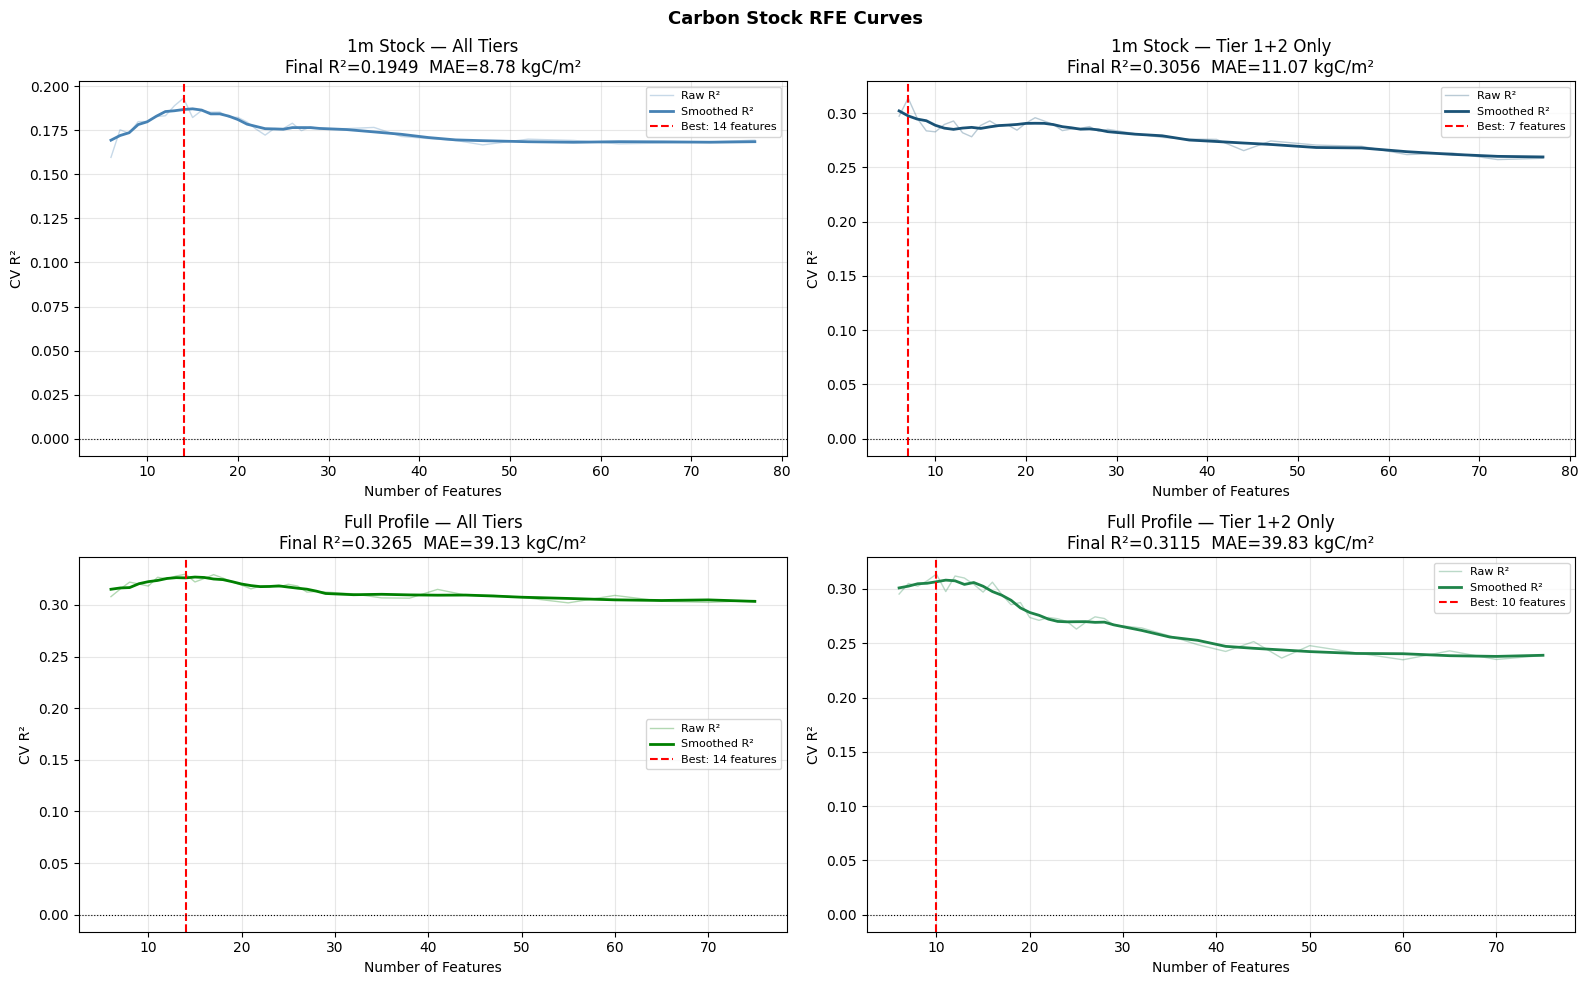

Saved: rfe_curves.png


In [4]:
# Cell 3 — RFE curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

def smooth(vals, window=5):
    out = []
    for i in range(len(vals)):
        lo = max(0, i-window//2)
        hi = min(len(vals), i+window//2+1)
        out.append(np.mean(vals[lo:hi]))
    return out

for i, label in enumerate(MODEL_LABELS):
    ax = axes[i]
    if label not in rfe:
        ax.set_title(f'{MODEL_TITLES[label]}\nNO RFE RESULTS')
        continue
    curve = rfe[label]['rfe_curve']
    ns  = [r['n_features'] for r in curve]
    r2s = [r['R2'] for r in curve]
    r2s_sm = smooth(r2s)
    color  = COLORS[label]
    ax.plot(ns, r2s,    color=color, alpha=0.3, lw=1,  label='Raw R²')
    ax.plot(ns, r2s_sm, color=color, lw=2,       label='Smoothed R²')
    ax.axvline(rfe[label]['n_best'], color='red', linestyle='--',
                label=f'Best: {rfe[label]["n_best"]} features')
    ax.axhline(0, color='black', lw=0.8, linestyle=':')
    ax.set_xlabel('Number of Features')
    ax.set_ylabel('CV R²')
    ax.set_title(f'{MODEL_TITLES[label]}\n'
                  f'Final R²={rfe[label]["final_r2"]:.4f}  '
                  f'MAE={rfe[label]["final_mae"]:.2f} kgC/m²')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Carbon Stock RFE Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/rfe_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rfe_curves.png')


In [5]:
# Cell 4 — Train final models with RFE features
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
final_cv = {}

for label, (dset, feats, target) in datasets.items():
    if label not in rfe:
        print(f'Skipping {label} — no RFE results')
        continue
    best_feats = rfe[label]['best_features']
    # Verify all features exist
    missing = [f for f in best_feats if f not in dset.columns]
    if missing:
        print(f'WARNING {label}: missing features {missing}')
        continue
    X = dset[best_feats].values
    y = dset[target].values
    if len(y) < N_FOLDS:
        print(f'Skipping {label} — only {len(y)} samples')
        continue
    print(f'\n{MODEL_TITLES[label]}: n={len(y):,}  features={len(best_feats)}')
    oof = np.zeros(len(y))
    importances = np.zeros(len(best_feats))
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(X)):
        rf = RandomForestRegressor(n_estimators=N_TREES, n_jobs=-1,
                                    random_state=RANDOM_STATE)
        rf.fit(X[tr_idx], y[tr_idx])
        oof[va_idx] = rf.predict(X[va_idx])
        importances += rf.feature_importances_
        print(f'  Fold {fold_i+1}/5 done')
    r2  = r2_score(y, oof)
    mae = mean_absolute_error(y, oof)
    print(f'  CV R2={r2:.4f}  MAE={mae:.2f} kgC/m2')
    final_cv[label] = {
        'oof': oof, 'y': y, 'r2': r2, 'mae': mae,
        'importances': importances/N_FOLDS,
        'best_feats': best_feats,
    }
    # Train on full dataset and save
    rf_final = RandomForestRegressor(n_estimators=N_TREES, n_jobs=-1,
                                      random_state=RANDOM_STATE)
    rf_final.fit(X, y)
    pkl_path  = f'{MDL_DIR}/{label}_final.pkl'
    feat_path = f'{MDL_DIR}/{label}_features.json'
    with open(pkl_path, 'wb') as f:
        pickle.dump(rf_final, f)
    with open(feat_path, 'w') as f:
        json.dump({'features': best_feats, 'target': target}, f, indent=2)
    print(f'  Saved: {pkl_path}')



1m Stock — All Tiers: n=3,728  features=14
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
  CV R2=0.1984  MAE=8.76 kgC/m2
  Saved: /scratch.global/ocon0444/peat_modeling/03_models/exp_carbon_stock/model_1a_1m_all_tiers_final.pkl

1m Stock — Tier 1+2 Only: n=685  features=7
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
  CV R2=0.3075  MAE=11.04 kgC/m2
  Saved: /scratch.global/ocon0444/peat_modeling/03_models/exp_carbon_stock/model_1b_1m_tier12_final.pkl

Full Profile — All Tiers: n=1,552  features=14
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
  CV R2=0.3267  MAE=39.21 kgC/m2
  Saved: /scratch.global/ocon0444/peat_modeling/03_models/exp_carbon_stock/model_2a_full_all_tiers_final.pkl

Full Profile — Tier 1+2 Only: n=325  features=10
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
  CV R2=0.3059  MAE=40.09 kgC/m2
  Saved: /scratch.global/ocon0444/peat_mod

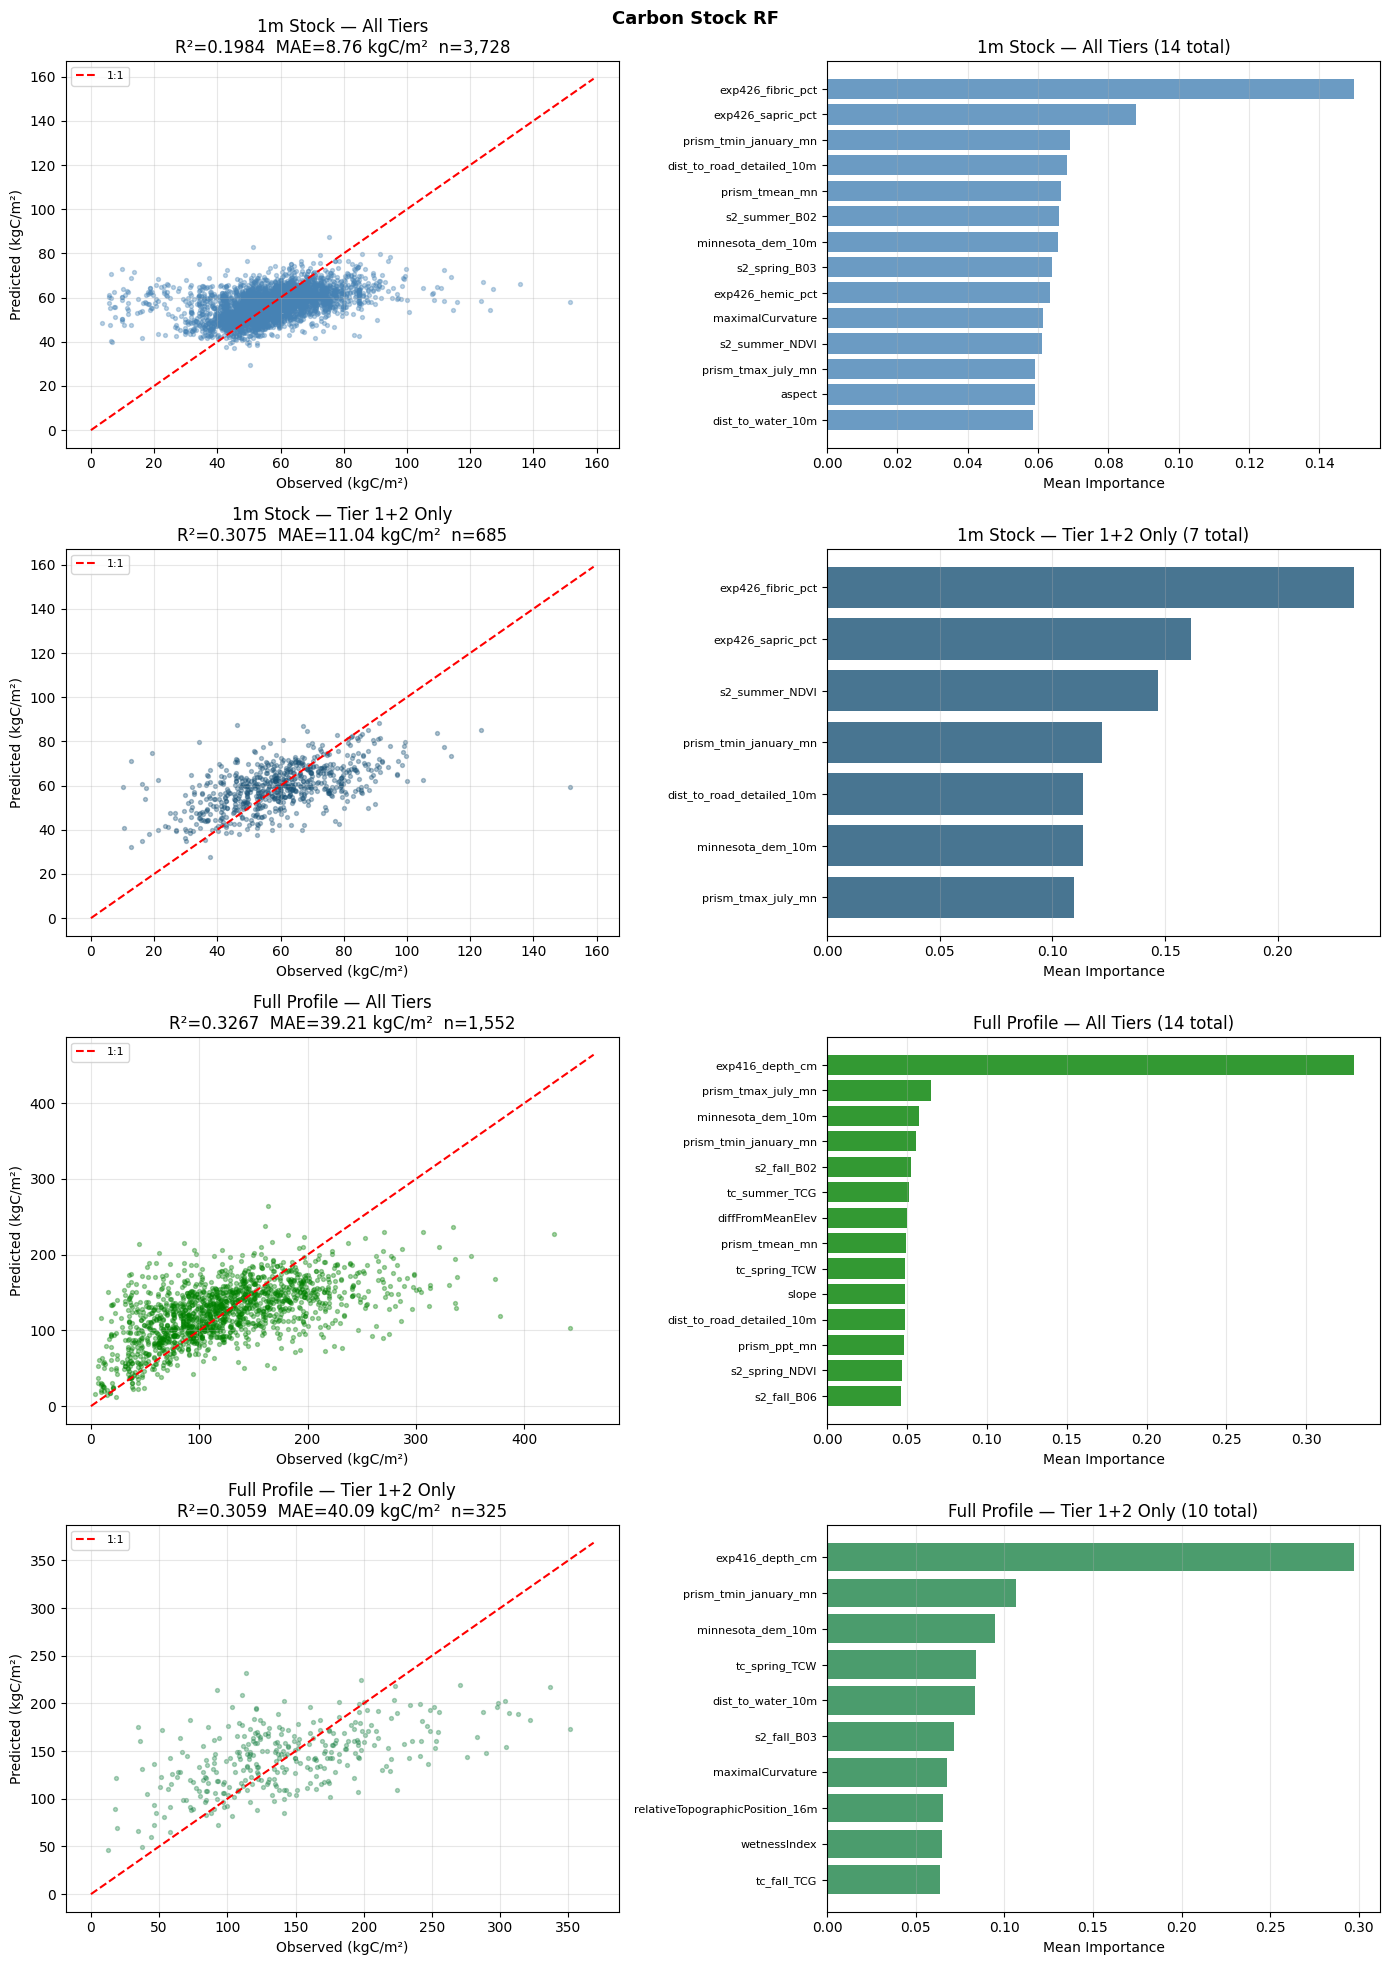

Saved: carbon_stock_results.png


In [6]:
# Cell 5 — Results plots
n_models = len(final_cv)
if n_models == 0:
    print('No models to plot — check cells above')
else:
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 5*n_models))
    if n_models == 1: axes = axes.reshape(1, 2)

    for row_i, (label, res) in enumerate(final_cv.items()):
        color = COLORS.get(label, 'steelblue')
        title = MODEL_TITLES.get(label, label)
        y, oof = res['y'], res['oof']

        # Predicted vs observed
        ax = axes[row_i, 0]
        ax.scatter(y, oof, alpha=0.35, s=8, color=color)
        lim = [0, max(y.max(), oof.max())*1.05]
        ax.plot(lim, lim, 'r--', lw=1.5, label='1:1')
        ax.set_xlabel('Observed (kgC/m²)')
        ax.set_ylabel('Predicted (kgC/m²)')
        ax.set_title(f'{title}\n'
                      f'R²={res["r2"]:.4f}  '
                      f'MAE={res["mae"]:.2f} kgC/m²  '
                      f'n={len(y):,}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # Feature importance
        ax = axes[row_i, 1]
        fi = pd.DataFrame({
            'feature':    res['best_feats'],
            'importance': res['importances']
        }).sort_values('importance', ascending=False).head(15)
        ax.barh(range(len(fi)), fi['importance'].values[::-1],
                 color=color, alpha=0.8)
        ax.set_yticks(range(len(fi)))
        ax.set_yticklabels(
            [f[:35] for f in fi['feature'].values[::-1]], fontsize=8)
        ax.set_xlabel('Mean Importance')
        ax.set_title(f'{title} ({len(res["best_feats"])} total)')
        ax.grid(alpha=0.3, axis='x')

    plt.suptitle('Carbon Stock RF', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{RES_DIR}/carbon_stock_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: carbon_stock_results.png')


In [7]:
# Cell 6 — Summary table
print('='*70)
print('CARBON STOCK RF MODEL SUMMARY')
print('='*70)
rows = []
for label, res in final_cv.items():
    rows.append({
        'Model':          MODEL_TITLES.get(label, label),
        'n':              len(res['y']),
        'RFE features':   len(res['best_feats']),
        'CV R²':          round(res['r2'], 4),
        'MAE (kgC/m²)':  round(res['mae'], 2),
        'Target mean':    round(res['y'].mean(), 1),
        'MAE/mean %':     round(100*res['mae']/res['y'].mean(), 1),
    })
print(pd.DataFrame(rows).to_string(index=False))
print()
print('Top features per model:')
for label, res in final_cv.items():
    fi = pd.DataFrame({'f': res['best_feats'],
                        'i': res['importances']})\
           .sort_values('i', ascending=False)
    top5 = fi.head(5)['f'].tolist()
    print(f'  {MODEL_TITLES.get(label,label)}: {top5}')
print()
print('Key findings:')
print('  - Tier 1+2 R2 > all-tiers R2 for 1m model: Tier 3 noise limits performance')
print('  - exp426 composition is top feature for 1m stock')
print('  - exp416 depth is top feature for full profile stock (expected)')
print('  - Full profile stock more predictable than 1m stock')
print('  - MAE ~15% of mean for 1m, ~35% for full profile')


CARBON STOCK RF MODEL SUMMARY
                       Model    n  RFE features  CV R²  MAE (kgC/m²)  Target mean  MAE/mean %
        1m Stock — All Tiers 3728            14 0.1984          8.76         57.2        15.3
    1m Stock — Tier 1+2 Only  685             7 0.3075         11.04         59.5        18.6
    Full Profile — All Tiers 1552            14 0.3267         39.21        123.3        31.8
Full Profile — Tier 1+2 Only  325            10 0.3059         40.09        143.1        28.0

Top features per model:
  1m Stock — All Tiers: ['exp426_fibric_pct', 'exp426_sapric_pct', 'prism_tmin_january_mn', 'dist_to_road_detailed_10m', 'prism_tmean_mn']
  1m Stock — Tier 1+2 Only: ['exp426_fibric_pct', 'exp426_sapric_pct', 's2_summer_NDVI', 'prism_tmin_january_mn', 'dist_to_road_detailed_10m']
  Full Profile — All Tiers: ['exp416_depth_cm', 'prism_tmax_july_mn', 'minnesota_dem_10m', 'prism_tmin_january_mn', 's2_fall_B02']
  Full Profile — Tier 1+2 Only: ['exp416_depth_cm', 'prism_tmi

=== GAP FILL TIER DEFINITIONS ===

Tier 1 (no RF):        soc_rf_pct == 0  — all SOC from measured lab or ash regression
Tier 2 (some RF):      0 < soc_rf_pct <= 50  — <50% of horizons used RF gap fill
Tier 3 (majority RF):  soc_rf_pct > 50  — majority of horizons used RF gap fill

RF gap fill has R2=-0.05 — essentially predicts the mean (~51% SOC).
Tier 3 targets are noisier because BD and SOC are less precisely known.

=== TIER BREAKDOWN — ALL ELIGIBLE PEDONS (n=3,828) ===
  Tier 1 (no RF)                :   503  (13.1%)
  Tier 2 (some RF)              :   202  (5.3%)
  Tier 3 (majority RF)          : 3,123  (81.6%)
  Unknown                       :     0  (0.0%)

=== 1m CARBON STOCK BY TIER ===
  Tier 1 (no RF)                : n=  485  mean=59.2  std=17.9  median=58.6 kgC/m2
  Tier 2 (some RF)              : n=  200  mean=60.3  std=16.8  median=60.1 kgC/m2
  Tier 3 (majority RF)          : n=3,043  mean=56.7  std=13.0  median=56.7 kgC/m2

=== FULL PROFILE STOCK BY TIER ===
  Tier 1

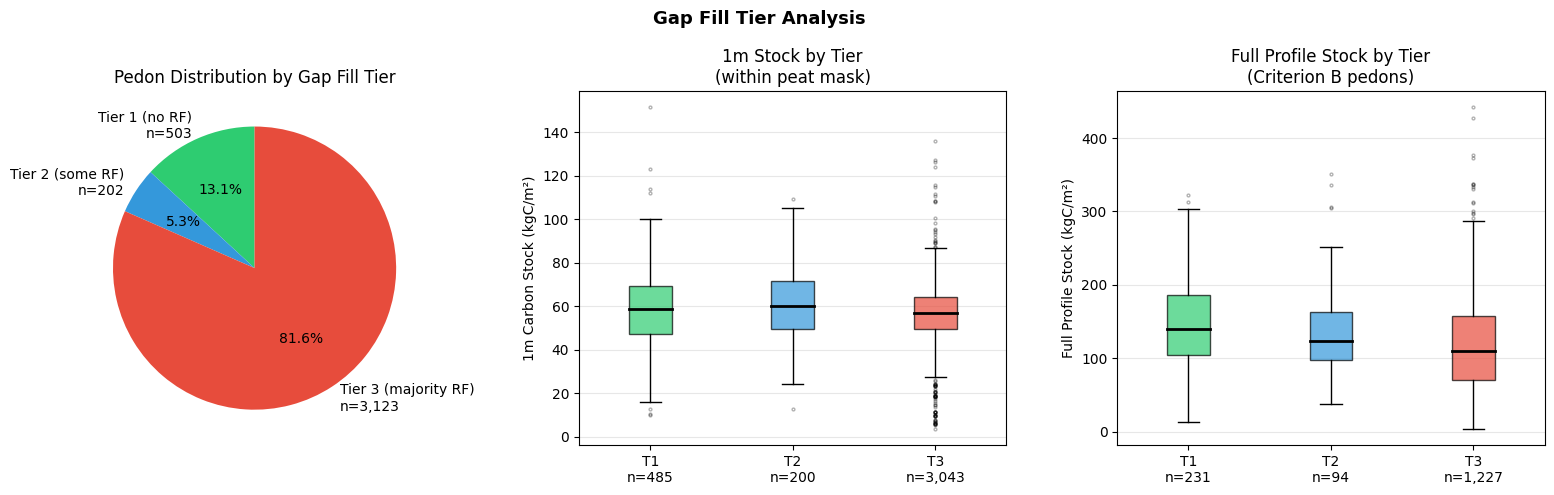

Saved: tier_analysis.png

=== KEY DIAGNOSTIC ===
Tier 1 mean 1m stock: 59.2 kgC/m2
Tier 3 mean 1m stock: 56.7 kgC/m2
Difference:           2.4 kgC/m2

If Tier 1 and Tier 3 means are similar: gap fill method has
little effect on the target distribution — results are robust.
If very different: Tier 3 targets are systematically biased.


In [8]:
# Cell 7 — Gap fill tier breakdown
print('=== GAP FILL TIER DEFINITIONS ===')
print()
print('Tier 1 (no RF):        soc_rf_pct == 0  — all SOC from measured lab or ash regression')
print('Tier 2 (some RF):      0 < soc_rf_pct <= 50  — <50% of horizons used RF gap fill')
print('Tier 3 (majority RF):  soc_rf_pct > 50  — majority of horizons used RF gap fill')
print()
print('RF gap fill has R2=-0.05 — essentially predicts the mean (~51% SOC).')
print('Tier 3 targets are noisier because BD and SOC are less precisely known.')
print()

# Overall tier breakdown
print('=== TIER BREAKDOWN — ALL ELIGIBLE PEDONS (n=3,828) ===')
tier_counts = df['gap_fill_tier'].value_counts()
for tier in ['Tier 1 (no RF)', 'Tier 2 (some RF)', 'Tier 3 (majority RF)', 'Unknown']:
    n = tier_counts.get(tier, 0)
    print(f'  {tier:<30}: {n:>5,}  ({100*n/len(df):.1f}%)')
print()

# Carbon stock stats by tier
print('=== 1m CARBON STOCK BY TIER ===')
for tier in ['Tier 1 (no RF)', 'Tier 2 (some RF)', 'Tier 3 (majority RF)']:
    sub = df1[df1['gap_fill_tier'] == tier]['C_stock_1m_kgm2'].dropna()
    if len(sub) == 0:
        continue
    print(f'  {tier:<30}: n={len(sub):>5,}  '
          f'mean={sub.mean():.1f}  '
          f'std={sub.std():.1f}  '
          f'median={sub.median():.1f} kgC/m2')
print()

print('=== FULL PROFILE STOCK BY TIER ===')
for tier in ['Tier 1 (no RF)', 'Tier 2 (some RF)', 'Tier 3 (majority RF)']:
    sub = df2[df2['gap_fill_tier'] == tier]['C_stock_full_kgm2'].dropna()
    if len(sub) == 0:
        continue
    print(f'  {tier:<30}: n={len(sub):>5,}  '
          f'mean={sub.mean():.1f}  '
          f'std={sub.std():.1f}  '
          f'median={sub.median():.1f} kgC/m2')
print()

# What data goes into each tier
print('=== WHAT DATA IS IN EACH TIER ===')
print()
print('Tier 1 — highest quality:')
print('  SOC: 100% from measured lab values or ash regression (R2=0.62)')
print('  BD:  100% from measured lab values or ash regression (R2=0.58)')
print('  Best for model training — targets are most accurate')
print()
print('Tier 2 — moderate quality:')
print('  SOC: <50% of horizons used RF gap fill, rest from lab/ash')
print('  BD:  same structure')
print('  Acceptable for training with caution')
print()
print('Tier 3 — lowest quality:')
print('  SOC: >50% of horizons used RF gap fill (R2=-0.05 — near random)')
print('  BD:  >50% of horizons used RF gap fill (R2=0.06 — near random)')
print('  Targets are noisy — model trained on these learns partly from noise')
print('  Makes up 81% of all eligible pedons')
print()

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart
tier_order  = ['Tier 1 (no RF)', 'Tier 2 (some RF)', 'Tier 3 (majority RF)']
tier_colors = ['#2ecc71', '#3498db', '#e74c3c']
counts = [tier_counts.get(t, 0) for t in tier_order]
axes[0].pie(counts, labels=[f'{t}\nn={c:,}' for t, c in zip(tier_order, counts)],
             colors=tier_colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Pedon Distribution by Gap Fill Tier')

# 1m stock boxplot by tier
data_1m = [df1[df1['gap_fill_tier']==t]['C_stock_1m_kgm2'].dropna().values
            for t in tier_order]
bp1 = axes[1].boxplot(data_1m,
                       labels=[f'T1\nn={len(data_1m[0]):,}',
                                f'T2\nn={len(data_1m[1]):,}',
                                f'T3\nn={len(data_1m[2]):,}'],
                       patch_artist=True,
                       medianprops=dict(color='black', lw=2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, c in zip(bp1['boxes'], tier_colors):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1].set_ylabel('1m Carbon Stock (kgC/m²)')
axes[1].set_title('1m Stock by Tier\n(within peat mask)')
axes[1].grid(alpha=0.3, axis='y')

# Full profile boxplot by tier
data_full = [df2[df2['gap_fill_tier']==t]['C_stock_full_kgm2'].dropna().values
              for t in tier_order]
counts_full = [len(d) for d in data_full]
valid_full  = [(d, f'T{i+1}\nn={c:,}', c) for i,(d,c) in
               enumerate(zip(data_full, counts_full)) if c > 0]
bp2 = axes[2].boxplot([v[0] for v in valid_full],
                       labels=[v[1] for v in valid_full],
                       patch_artist=True,
                       medianprops=dict(color='black', lw=2),
                       flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, (_, _, _) in zip(bp2['boxes'], valid_full):
    patch.set_facecolor(tier_colors[0]); patch.set_alpha(0.7)
for patch, c in zip(bp2['boxes'], tier_colors[:len(valid_full)]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[2].set_ylabel('Full Profile Stock (kgC/m²)')
axes[2].set_title('Full Profile Stock by Tier\n(Criterion B pedons)')
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('Gap Fill Tier Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/tier_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tier_analysis.png')

# Key diagnostic
print()
print('=== KEY DIAGNOSTIC ===')
t1_mean = df1[df1['gap_fill_tier']=='Tier 1 (no RF)']['C_stock_1m_kgm2'].mean()
t3_mean = df1[df1['gap_fill_tier']=='Tier 3 (majority RF)']['C_stock_1m_kgm2'].mean()
print(f'Tier 1 mean 1m stock: {t1_mean:.1f} kgC/m2')
print(f'Tier 3 mean 1m stock: {t3_mean:.1f} kgC/m2')
print(f'Difference:           {abs(t1_mean-t3_mean):.1f} kgC/m2')
print()
print('If Tier 1 and Tier 3 means are similar: gap fill method has')
print('little effect on the target distribution — results are robust.')
print('If very different: Tier 3 targets are systematically biased.')

Plotting n=1,552 Criterion B pedons with full stock + depth
Depth range: 5 – 810 cm
Stock range: 3.6 – 441.9 kgC/m²


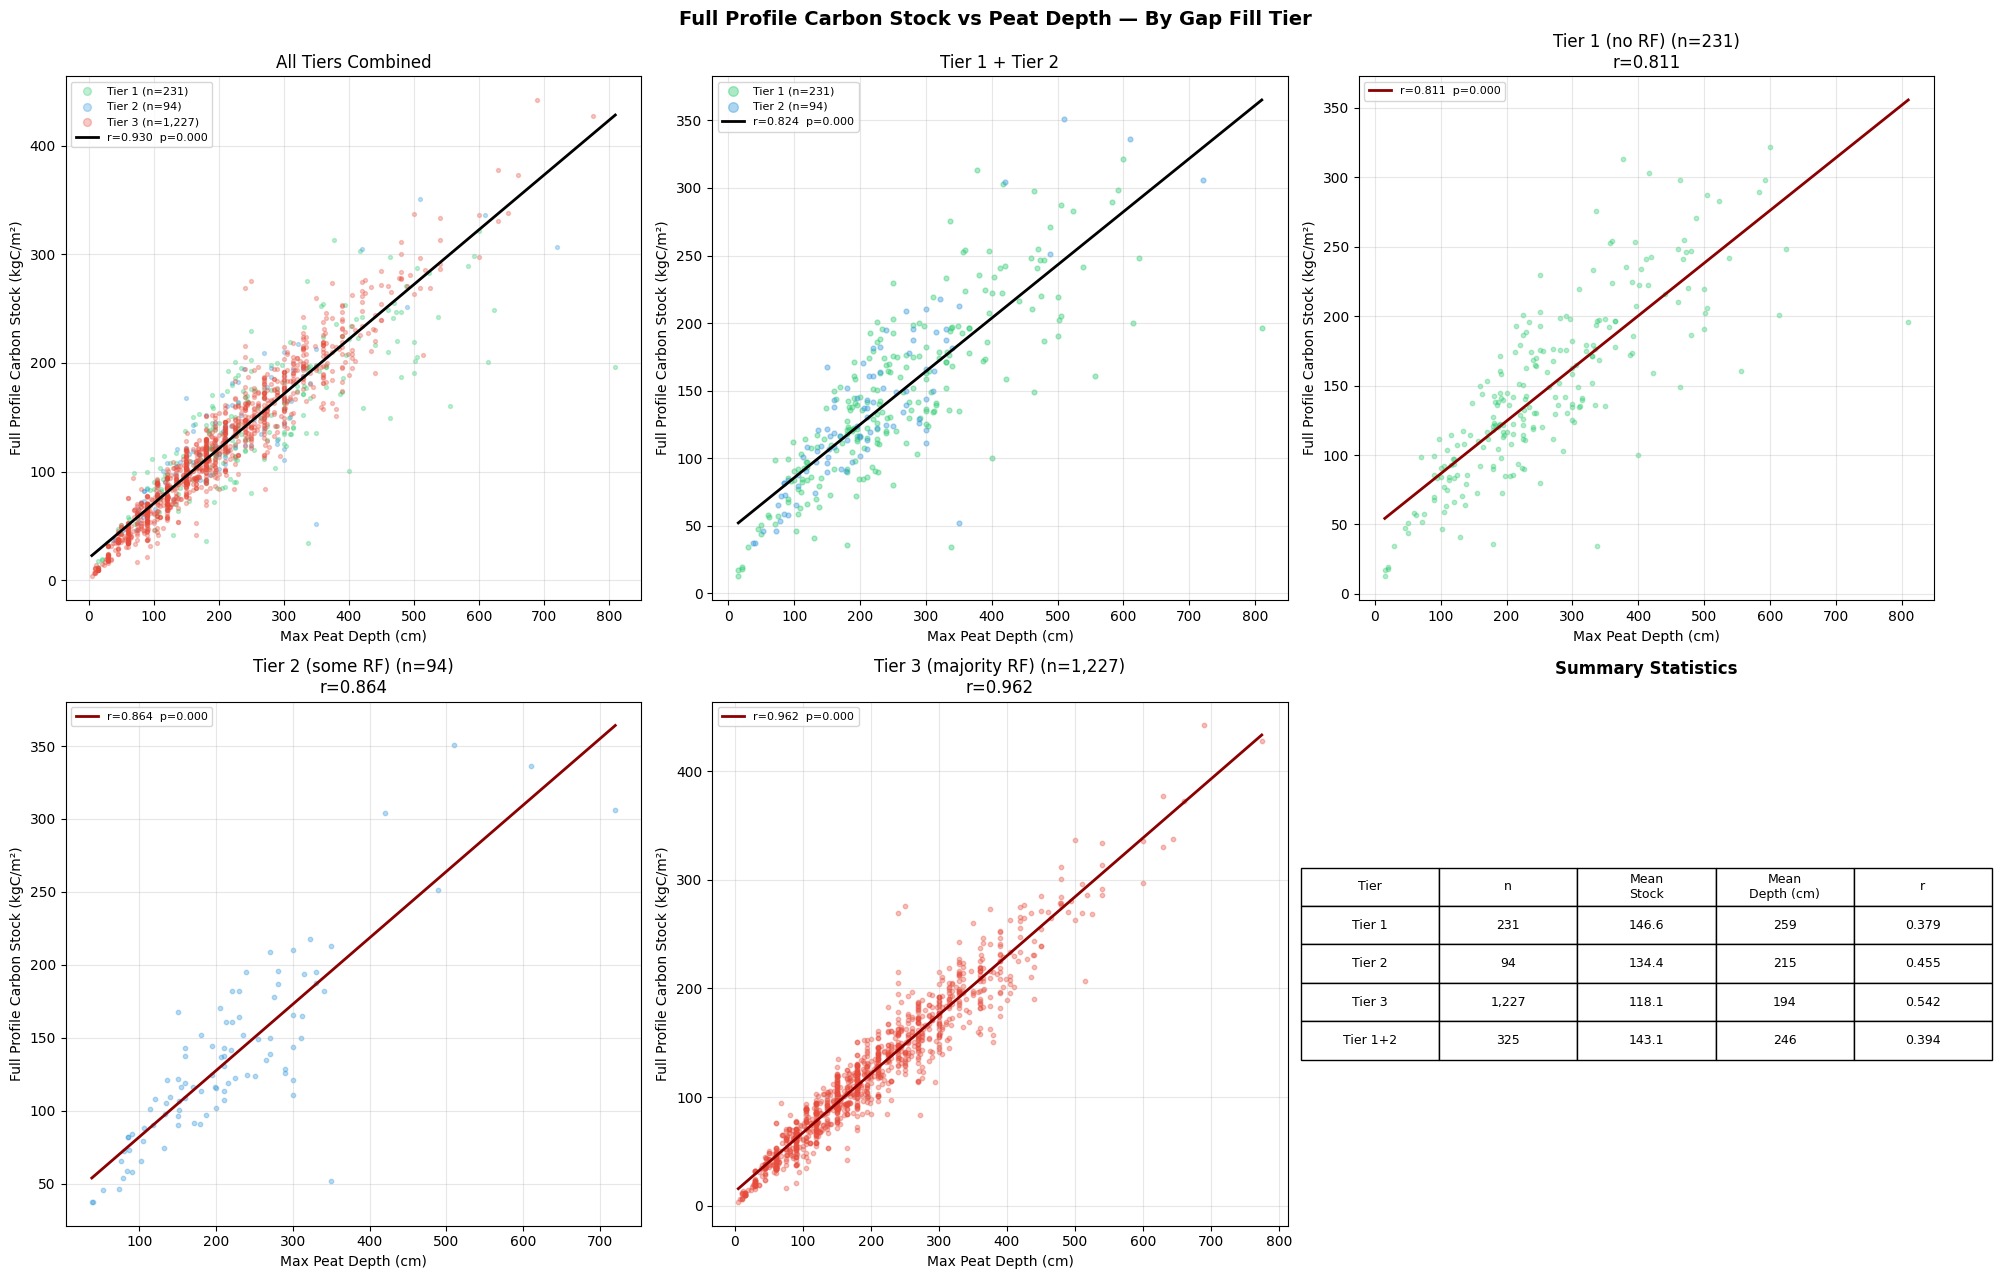

Saved: full_stock_vs_depth_by_tier.png


In [16]:
# Carbon stock vs peat depth scatter plots by tier
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Need max_peat_depth_cm from pedon CSV — merge if not already present
if 'max_peat_depth_cm' not in df.columns:
    pedon_depth = pd.read_csv(
        f'{BASE_I}/02_outputs/carbon_stock_pedon.csv',
        usecols=[ID, 'max_peat_depth_cm'], low_memory=False)
    df = df.merge(pedon_depth, on=ID, how='left')

# Work from df2 (full profile stock, Criterion B pedons within peat mask)
plot_df = df2[['C_stock_full_kgm2', 'max_peat_depth_cm', 'gap_fill_tier']].dropna().copy()
print(f'Plotting n={len(plot_df):,} Criterion B pedons with full stock + depth')
print(f'Depth range: {plot_df["max_peat_depth_cm"].min():.0f} – {plot_df["max_peat_depth_cm"].max():.0f} cm')
print(f'Stock range: {plot_df["C_stock_full_kgm2"].min():.1f} – {plot_df["C_stock_full_kgm2"].max():.1f} kgC/m²')

TIER_ORDER  = ['Tier 1 (no RF)', 'Tier 2 (some RF)', 'Tier 3 (majority RF)']
TIER_COLORS = {'Tier 1 (no RF)': '#2ecc71',
               'Tier 2 (some RF)': '#3498db',
               'Tier 3 (majority RF)': '#e74c3c'}
TIER_SHORT  = {'Tier 1 (no RF)': 'Tier 1',
               'Tier 2 (some RF)': 'Tier 2',
               'Tier 3 (majority RF)': 'Tier 3'}

def add_regression(ax, x, y, color='black', label=True):
    if len(x) < 3:
        return
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope*x_line + intercept, '-', color=color, lw=2,
            label=f'r={r:.3f}  p={p:.3f}' if label else None)
    return r, p

fig, axes = plt.subplots(2, 3, figsize=(20, 13))

# ── Panel 1: All tiers together ───────────────────────────────────
ax = axes[0, 0]
for tier in TIER_ORDER:
    sub = plot_df[plot_df['gap_fill_tier'] == tier]
    if len(sub) == 0: continue
    ax.scatter(sub['max_peat_depth_cm'], sub['C_stock_full_kgm2'],
               alpha=0.3, s=8, color=TIER_COLORS[tier],
               label=f'{TIER_SHORT[tier]} (n={len(sub):,})')
x_all = plot_df['max_peat_depth_cm'].values
y_all = plot_df['C_stock_full_kgm2'].values
add_regression(ax, x_all, y_all, color='black', label=True)
ax.set_xlabel('Max Peat Depth (cm)')
ax.set_ylabel('Full Profile Carbon Stock (kgC/m²)')
ax.set_title('All Tiers Combined')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)

# ── Panel 2: Tier 1 + Tier 2 only ────────────────────────────────
ax = axes[0, 1]
sub12 = plot_df[plot_df['gap_fill_tier'].isin(['Tier 1 (no RF)', 'Tier 2 (some RF)'])]
for tier in ['Tier 1 (no RF)', 'Tier 2 (some RF)']:
    sub = plot_df[plot_df['gap_fill_tier'] == tier]
    if len(sub) == 0: continue
    ax.scatter(sub['max_peat_depth_cm'], sub['C_stock_full_kgm2'],
               alpha=0.4, s=12, color=TIER_COLORS[tier],
               label=f'{TIER_SHORT[tier]} (n={len(sub):,})')
if len(sub12) >= 3:
    r12, p12 = add_regression(ax, sub12['max_peat_depth_cm'].values,
                               sub12['C_stock_full_kgm2'].values,
                               color='black', label=True)
ax.set_xlabel('Max Peat Depth (cm)')
ax.set_ylabel('Full Profile Carbon Stock (kgC/m²)')
ax.set_title('Tier 1 + Tier 2')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)

# ── Panels 3-5: Each tier separately ─────────────────────────────
tier_axes = [axes[0, 2], axes[1, 0], axes[1, 1]]
for ax, tier in zip(tier_axes, TIER_ORDER):
    sub = plot_df[plot_df['gap_fill_tier'] == tier]
    color = TIER_COLORS[tier]
    if len(sub) == 0:
        ax.set_title(f'{tier}\nn=0')
        continue
    ax.scatter(sub['max_peat_depth_cm'], sub['C_stock_full_kgm2'],
               alpha=0.35, s=10, color=color)
    if len(sub) >= 3:
        r, p = add_regression(ax, sub['max_peat_depth_cm'].values,
                               sub['C_stock_full_kgm2'].values,
                               color='darkred', label=True)
        title_r = f'r={r:.3f}'
    else:
        title_r = 'n too small'
    ax.set_xlabel('Max Peat Depth (cm)')
    ax.set_ylabel('Full Profile Carbon Stock (kgC/m²)')
    ax.set_title(f'{tier} (n={len(sub):,})\n{title_r}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# ── Panel 6: Summary stats table ─────────────────────────────────
ax = axes[1, 2]
ax.axis('off')
rows = []
for tier in TIER_ORDER + ['Tier 1+2']:
    if tier == 'Tier 1+2':
        sub = plot_df[plot_df['gap_fill_tier'].isin(
            ['Tier 1 (no RF)', 'Tier 2 (some RF)'])]
        label = 'Tier 1+2'
    else:
        sub = plot_df[plot_df['gap_fill_tier'] == tier]
        label = TIER_SHORT[tier]
    if len(sub) < 3:
        rows.append([label, str(len(sub)), '—', '—', '—'])
        continue
    r, p, _, _, _ = stats.linregress(
        sub['max_peat_depth_cm'], sub['C_stock_full_kgm2'])
    rows.append([
        label,
        f'{len(sub):,}',
        f'{sub["C_stock_full_kgm2"].mean():.1f}',
        f'{sub["max_peat_depth_cm"].mean():.0f}',
        f'{r:.3f}',
    ])

col_labels = ['Tier', 'n', 'Mean\nStock', 'Mean\nDepth (cm)', 'r']
table = ax.table(cellText=rows, colLabels=col_labels,
                  loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.0)
ax.set_title('Summary Statistics', fontweight='bold', pad=20)

plt.suptitle('Full Profile Carbon Stock vs Peat Depth — By Gap Fill Tier',
             fontsize=14, fontweight='bold')
plt.tight_layout()

FIGS = '/scratch.global/ocon0444/peat_inventory/03_figures'
plt.savefig(f'{FIGS}/full_stock_vs_depth_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: full_stock_vs_depth_by_tier.png')

In [14]:
# ── Summary stats as text table ─────────────────────────────
from scipy import stats

rows = []

for tier in TIER_ORDER + ['Tier 1+2']:
    if tier == 'Tier 1+2':
        sub = plot_df[plot_df['gap_fill_tier'].isin(
            ['Tier 1 (no RF)', 'Tier 2 (some RF)'])]
        label = 'Tier 1+2'
    else:
        sub = plot_df[plot_df['gap_fill_tier'] == tier]
        label = TIER_SHORT[tier]

    if len(sub) < 3:
        rows.append([label, len(sub), '—', '—', '—'])
        continue

    slope, intercept, r, p, _ = stats.linregress(
        sub['max_peat_depth_cm'], sub['C_stock_full_kgm2'])

    rows.append([
        label,
        len(sub),
        f'{sub["C_stock_full_kgm2"].mean():.1f}',
        f'{sub["max_peat_depth_cm"].mean():.0f}',
        f'{r:.3f}'
    ])

# Print nicely formatted table
header = ['Tier', 'n', 'Mean Stock', 'Mean Depth (cm)', 'r']

print('\nSummary Statistics\n' + '-'*60)
print(f'{header[0]:<10} {header[1]:>8} {header[2]:>15} {header[3]:>18} {header[4]:>8}')
print('-'*60)

for row in rows:
    print(f'{row[0]:<10} {row[1]:>8} {row[2]:>15} {row[3]:>18} {row[4]:>8}')

print('-'*60)


Summary Statistics
------------------------------------------------------------
Tier              n      Mean Stock    Mean Depth (cm)        r
------------------------------------------------------------
Tier 1          231           146.6                259    0.811
Tier 2           94           134.4                215    0.864
Tier 3         1227           118.1                194    0.962
Tier 1+2        325           143.1                246    0.824
------------------------------------------------------------


Plotting n=1,552 Criterion B pedons with full stock + depth


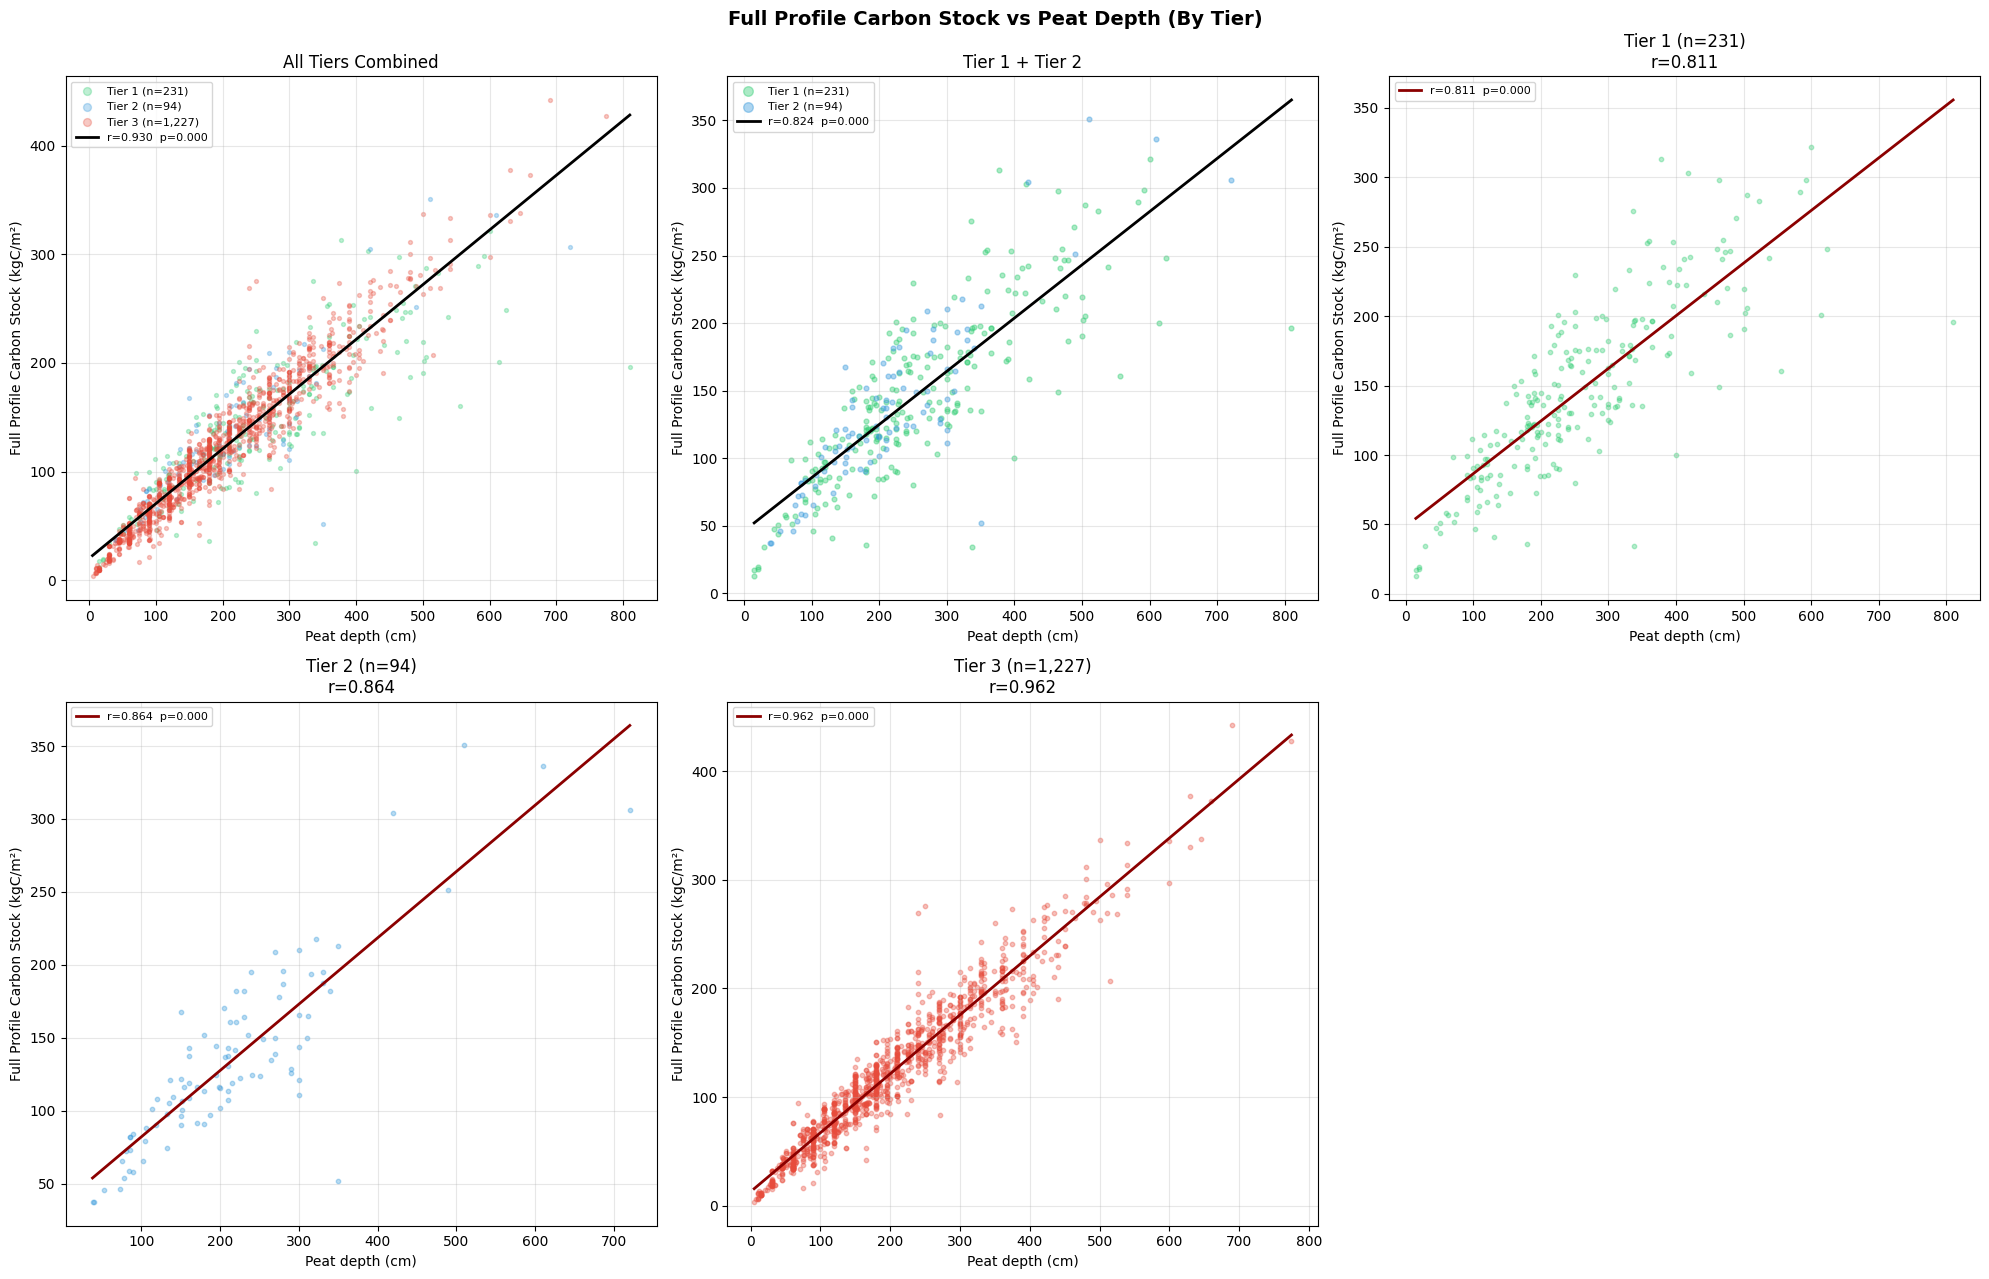

Saved: full_stock_vs_depth_by_tier.png


In [19]:
# Carbon stock vs peat depth scatter plots by tier
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Need max_peat_depth_cm from pedon CSV — merge if not already present
if 'max_peat_depth_cm' not in df.columns:
    pedon_depth = pd.read_csv(
        f'{BASE_I}/02_outputs/carbon_stock_pedon.csv',
        usecols=[ID, 'max_peat_depth_cm'], low_memory=False)
    df = df.merge(pedon_depth, on=ID, how='left')

# Work from df2 (full profile stock, Criterion B pedons within peat mask)
plot_df = df2[['C_stock_full_kgm2', 'max_peat_depth_cm', 'gap_fill_tier']].dropna().copy()
print(f'Plotting n={len(plot_df):,} Criterion B pedons with full stock + depth')

TIER_ORDER  = ['Tier 1 (no RF)', 'Tier 2 (some RF)', 'Tier 3 (majority RF)']
TIER_COLORS = {'Tier 1 (no RF)': '#2ecc71',
               'Tier 2 (some RF)': '#3498db',
               'Tier 3 (majority RF)': '#e74c3c'}
TIER_SHORT  = {'Tier 1 (no RF)': 'Tier 1',
               'Tier 2 (some RF)': 'Tier 2',
               'Tier 3 (majority RF)': 'Tier 3'}

def add_regression(ax, x, y, color='black', label=True):
    if len(x) < 3:
        return
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, slope*x_line + intercept, '-', color=color, lw=2,
            label=f'r={r:.3f}  p={p:.3f}' if label else None)
    return r, p

# Updated layout (2x3 -> now using only 5 panels)
fig, axes = plt.subplots(2, 3, figsize=(20, 13))

# ── Panel 1: All tiers together ───────────────────────────────────
ax = axes[0, 0]
for tier in TIER_ORDER:
    sub = plot_df[plot_df['gap_fill_tier'] == tier]
    if len(sub) == 0: continue
    ax.scatter(sub['max_peat_depth_cm'], sub['C_stock_full_kgm2'],
               alpha=0.3, s=8, color=TIER_COLORS[tier],
               label=f'{TIER_SHORT[tier]} (n={len(sub):,})')

x_all = plot_df['max_peat_depth_cm'].values
y_all = plot_df['C_stock_full_kgm2'].values
add_regression(ax, x_all, y_all, color='black', label=True)

ax.set_xlabel('Peat depth (cm)')
ax.set_ylabel('Full Profile Carbon Stock (kgC/m²)')
ax.set_title('All Tiers Combined')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)

# ── Panel 2: Tier 1 + Tier 2 only ────────────────────────────────
ax = axes[0, 1]
sub12 = plot_df[plot_df['gap_fill_tier'].isin(['Tier 1 (no RF)', 'Tier 2 (some RF)'])]

for tier in ['Tier 1 (no RF)', 'Tier 2 (some RF)']:
    sub = plot_df[plot_df['gap_fill_tier'] == tier]
    if len(sub) == 0: continue
    ax.scatter(sub['max_peat_depth_cm'], sub['C_stock_full_kgm2'],
               alpha=0.4, s=12, color=TIER_COLORS[tier],
               label=f'{TIER_SHORT[tier]} (n={len(sub):,})')

if len(sub12) >= 3:
    add_regression(ax,
                   sub12['max_peat_depth_cm'].values,
                   sub12['C_stock_full_kgm2'].values,
                   color='black', label=True)

ax.set_xlabel('Peat depth (cm)')
ax.set_ylabel('Full Profile Carbon Stock (kgC/m²)')
ax.set_title('Tier 1 + Tier 2')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3)

# ── Panels 3-5: Each tier separately ─────────────────────────────
tier_axes = [axes[0, 2], axes[1, 0], axes[1, 1]]

for ax, tier in zip(tier_axes, TIER_ORDER):
    sub = plot_df[plot_df['gap_fill_tier'] == tier]
    color = TIER_COLORS[tier]

    if len(sub) == 0:
        ax.set_title(f'{TIER_SHORT[tier]}\nn=0')
        continue

    ax.scatter(sub['max_peat_depth_cm'], sub['C_stock_full_kgm2'],
               alpha=0.35, s=10, color=color)

    if len(sub) >= 3:
        r, p = add_regression(ax,
                              sub['max_peat_depth_cm'].values,
                              sub['C_stock_full_kgm2'].values,
                              color='darkred', label=True)
        title_r = f'r={r:.3f}'
    else:
        title_r = 'n too small'

    ax.set_xlabel('Peat depth (cm)')
    ax.set_ylabel('Full Profile Carbon Stock (kgC/m²)')
    ax.set_title(f'{TIER_SHORT[tier]} (n={len(sub):,})\n{title_r}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Remove empty last subplot
axes[1, 2].axis('off')

plt.suptitle('Full Profile Carbon Stock vs Peat Depth (By Tier)',
             fontsize=14, fontweight='bold')

plt.tight_layout()

FIGS = '/scratch.global/ocon0444/peat_inventory/03_figures'
plt.savefig(f'{FIGS}/full_stock_vs_depth_by_tier.png',
            dpi=150, bbox_inches='tight')

plt.show()
print('Saved: full_stock_vs_depth_by_tier.png')

Running CV predictions (100 trees for speed)...
  1m Stock — All Tiers (n=3,732)...
    R2=0.1863  MAE=8.84 kgC/m2
  1m Stock — Tier 1+2 Only (n=685)...
    R2=0.2977  MAE=11.21 kgC/m2
  Full Profile — All Tiers (n=1,553)...
    R2=0.3204  MAE=39.04 kgC/m2
  Full Profile — Tier 1+2 (n=325)...
    R2=0.2658  MAE=40.64 kgC/m2


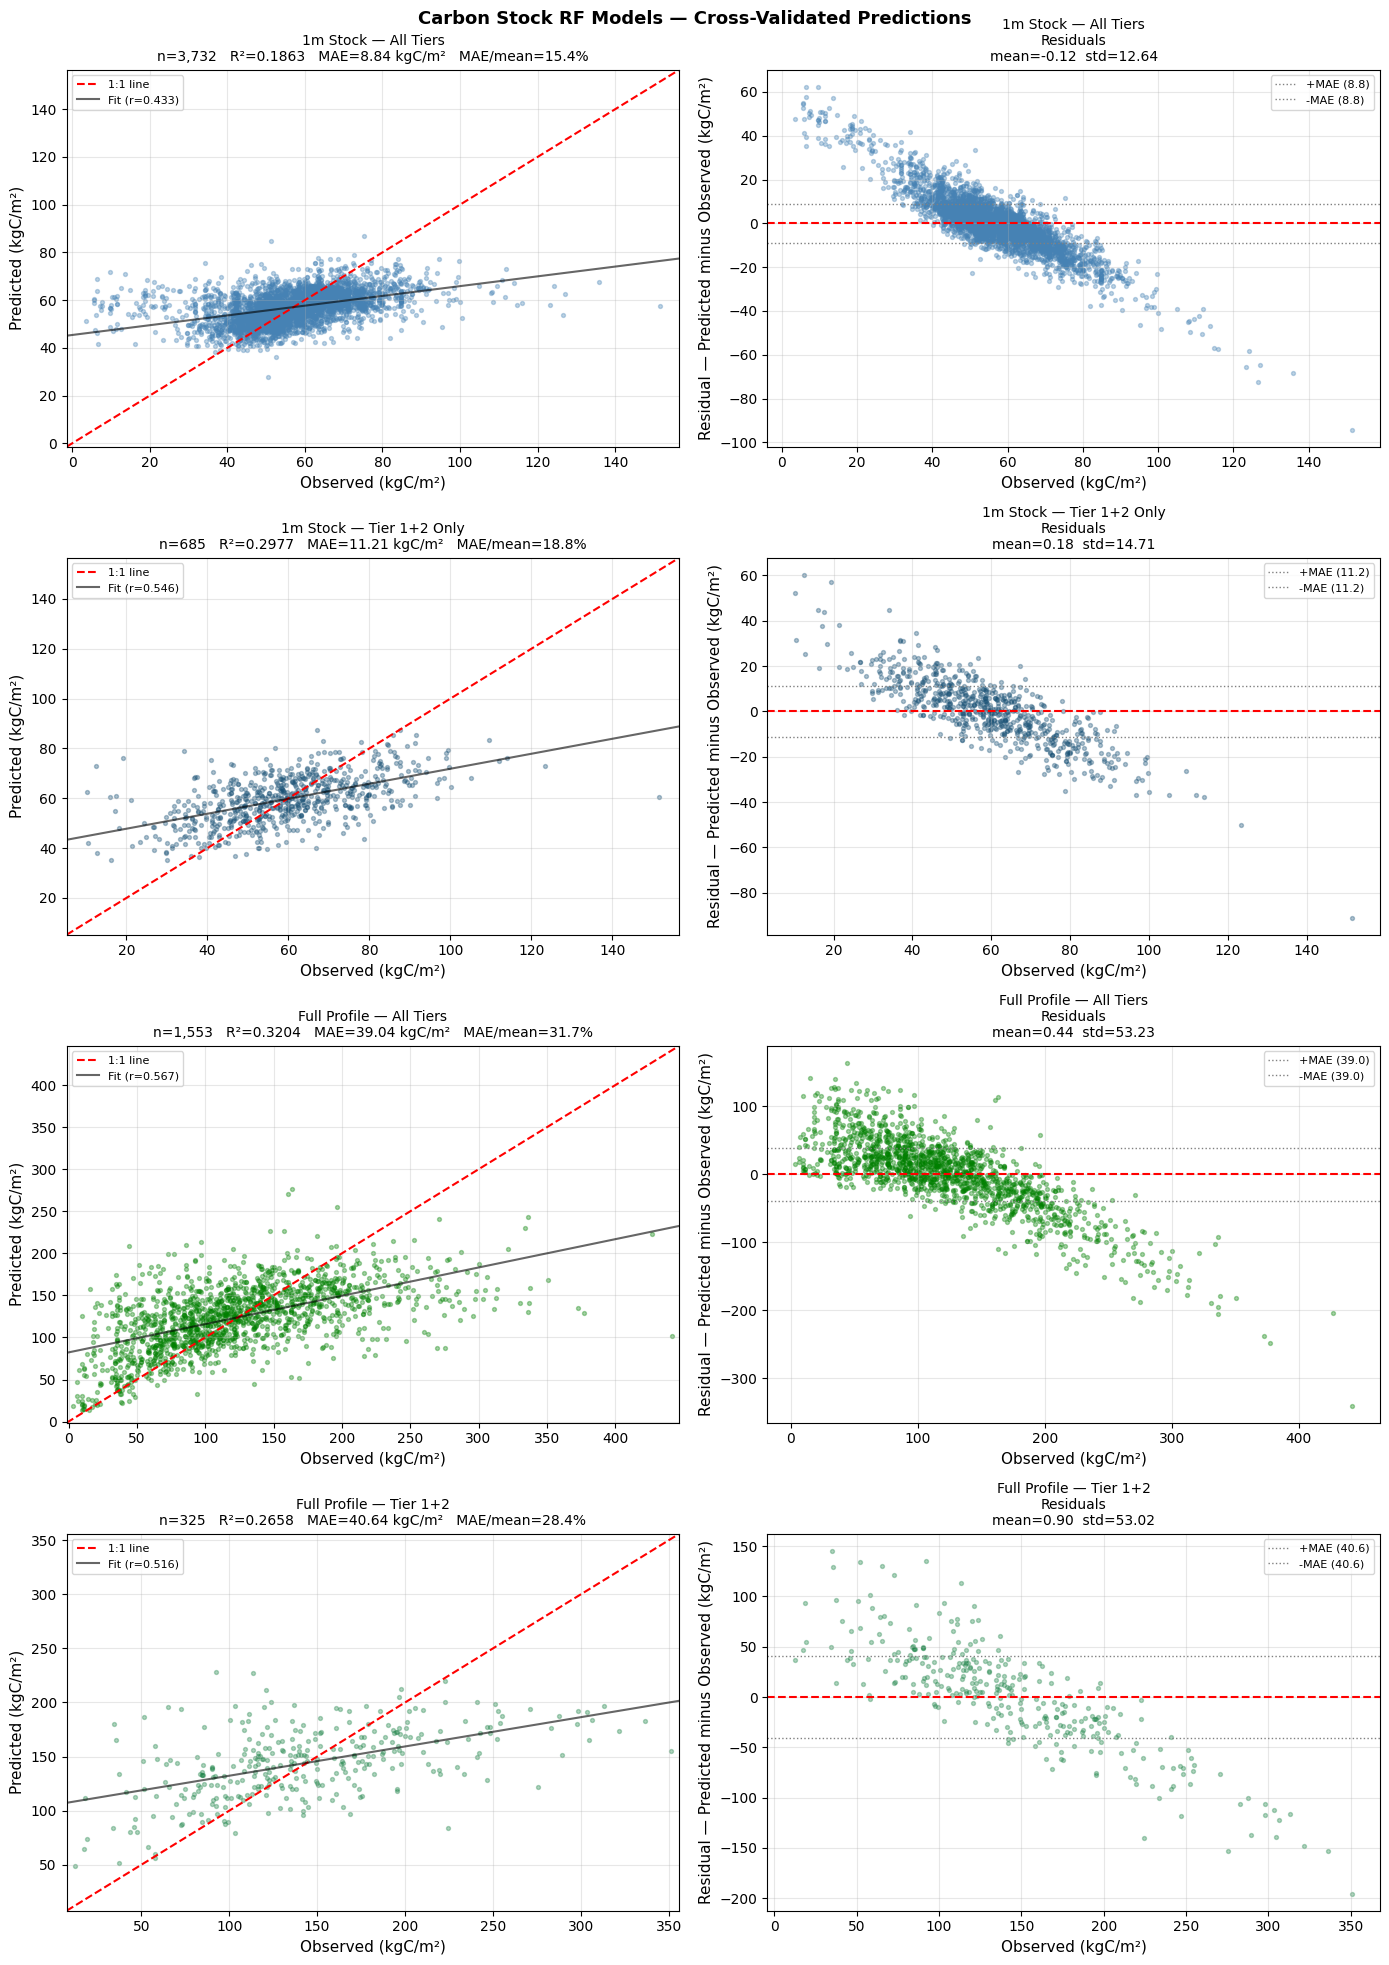

Saved: carbon_stock_cv_results.png

Model                               n   Obs mean   Obs std       R2      MAE   MAE/mean
-------------------------------------------------------------------------------------
1m Stock — All Tiers            3,732       57.3      14.0   0.1863     8.84      15.4%
1m Stock — Tier 1+2 Only          685       59.5      17.5   0.2977    11.21      18.8%
Full Profile — All Tiers        1,553      123.3      64.6   0.3204    39.04      31.7%
Full Profile — Tier 1+2           325      143.1      61.9   0.2658    40.64      28.4%


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
from scipy import stats

BASE_M  = '/scratch.global/ocon0444/peat_modeling'
BASE_I  = '/scratch.global/ocon0444/peat_inventory'
RES_DIR = f'{BASE_M}/05_results/exp_carbon_stock'

# ── Reload data (same as previous cell) ───────────────────────────
CSV_PATH = f'{BASE_M}/00_data/processed/carbon_stock_features_extracted.csv'
PED_PATH = f'{BASE_I}/02_outputs/carbon_stock_pedon.csv'
ID = 'DNR Peat Inventory ID #'

feat_df = pd.read_csv(CSV_PATH, low_memory=False)
pedon   = pd.read_csv(PED_PATH, low_memory=False)

def assign_tier(rf_pct):
    if pd.isna(rf_pct): return 'Unknown'
    if rf_pct == 0:     return 'Tier 1 (no RF)'
    if rf_pct <= 50:    return 'Tier 2 (some RF)'
    return 'Tier 3 (majority RF)'

pedon['gap_fill_tier'] = pedon['soc_rf_pct'].apply(assign_tier)
PEDON_COLS = [ID,'criteria_A','criteria_B','gap_fill_tier',
              'C_stock_1m_kgm2','C_stock_full_kgm2','soc_rf_pct']
for col in PEDON_COLS:
    if col != ID and col in feat_df.columns:
        feat_df = feat_df.drop(columns=[col])
df = feat_df.merge(pedon[PEDON_COLS], on=ID, how='inner')
if 'dist_from_waterbody_edge_10m' in df.columns:
    df['dist_from_waterbody_edge_10m'] = df['dist_from_waterbody_edge_10m'].fillna(99999)

peat_mask = df['exp410_prob'] >= 0.33
crit_b    = df['criteria_B'] == True
TIER12    = ['Tier 1 (no RF)','Tier 2 (some RF)']

with open(f'{BASE_M}/03_models/exp_carbon_stock/model_1a_1m_all_tiers_features.json') as f:
    feats_1m = json.load(f)['features']
with open(f'{BASE_M}/03_models/exp_carbon_stock/model_2a_full_all_tiers_features.json') as f:
    feats_full = json.load(f)['features']

df1    = df[peat_mask & df['C_stock_1m_kgm2'].notna()].dropna(subset=feats_1m).copy()
df1_hq = df1[df1['gap_fill_tier'].isin(TIER12)].copy()
df2    = df[peat_mask & crit_b & df['C_stock_full_kgm2'].notna()].dropna(subset=feats_full).copy()
df2_hq = df2[df2['gap_fill_tier'].isin(TIER12)].copy()

# ── Load RFE OOF predictions ───────────────────────────────────────
# Re-run CV to get OOF predictions for plotting
# (RFE JSON only stores final metrics, not the actual predictions)
import pickle
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
N_TREES = 300
RANDOM_STATE = 42

from sklearn.ensemble import RandomForestRegressor

def get_oof(df_sub, feats, target):
    X = df_sub[feats].values
    y = df_sub[target].values
    oof = np.zeros(len(y))
    for tr_idx, va_idx in kf.split(X):
        rf = RandomForestRegressor(n_estimators=100, n_jobs=-1,
                                    random_state=RANDOM_STATE)
        rf.fit(X[tr_idx], y[tr_idx])
        oof[va_idx] = rf.predict(X[va_idx])
    return y, oof

print('Running CV predictions (100 trees for speed)...')
models_data = [
    ('1m Stock — All Tiers',       df1,    feats_1m,   'C_stock_1m_kgm2',   'steelblue'),
    ('1m Stock — Tier 1+2 Only',   df1_hq, feats_1m,   'C_stock_1m_kgm2',   '#1a5276'),
    ('Full Profile — All Tiers',   df2,    feats_full, 'C_stock_full_kgm2', 'green'),
    ('Full Profile — Tier 1+2',    df2_hq, feats_full, 'C_stock_full_kgm2', '#1e8449'),
]

results = []
for title, dset, feats, target, color in models_data:
    if len(dset) < 5:
        print(f'  Skipping {title} — n={len(dset)}')
        continue
    print(f'  {title} (n={len(dset):,})...')
    y, oof = get_oof(dset, feats, target)
    r2  = r2_score(y, oof)
    mae = mean_absolute_error(y, oof)
    results.append({
        'title': title, 'y': y, 'oof': oof,
        'r2': r2, 'mae': mae, 'color': color,
        'n': len(y), 'mean': y.mean(), 'std': y.std(),
    })
    print(f'    R2={r2:.4f}  MAE={mae:.2f} kgC/m2')

# ── Figure ─────────────────────────────────────────────────────────
n_models = len(results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5*n_models))
if n_models == 1: axes = axes.reshape(1, 2)

for i, res in enumerate(results):
    y, oof = res['y'], res['oof']
    color  = res['color']

    # Left — predicted vs observed
    ax = axes[i, 0]
    ax.scatter(y, oof, alpha=0.35, s=8, color=color)
    lim = [min(y.min(), oof.min())-5, max(y.max(), oof.max())+5]
    ax.plot(lim, lim, 'r--', lw=1.5, label='1:1 line')

    # Regression line through predictions
    slope, intercept, r_val, _, _ = stats.linregress(y, oof)
    x_line = np.linspace(lim[0], lim[1], 200)
    ax.plot(x_line, slope*x_line+intercept, 'k-', lw=1.5, alpha=0.6,
             label=f'Fit (r={r_val:.3f})')

    ax.set_xlabel('Observed (kgC/m²)', fontsize=11)
    ax.set_ylabel('Predicted (kgC/m²)', fontsize=11)
    ax.set_title(
        f'{res["title"]}\n'
        f'n={res["n"]:,}   R²={res["r2"]:.4f}   '
        f'MAE={res["mae"]:.2f} kgC/m²   '
        f'MAE/mean={100*res["mae"]/res["mean"]:.1f}%',
        fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)

    # Right — residuals vs observed
    ax = axes[i, 1]
    residuals = oof - y
    ax.scatter(y, residuals, alpha=0.35, s=8, color=color)
    ax.axhline(0, color='red', lw=1.5, linestyle='--')
    ax.axhline(res['mae'], color='gray', lw=1, linestyle=':',
                label=f'+MAE ({res["mae"]:.1f})')
    ax.axhline(-res['mae'], color='gray', lw=1, linestyle=':',
                label=f'-MAE ({res["mae"]:.1f})')
    ax.set_xlabel('Observed (kgC/m²)', fontsize=11)
    ax.set_ylabel('Residual — Predicted minus Observed (kgC/m²)', fontsize=11)
    ax.set_title(f'{res["title"]}\nResiduals\nmean={residuals.mean():.2f}  std={residuals.std():.2f}', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Carbon Stock RF Models — Cross-Validated Predictions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RES_DIR}/carbon_stock_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: carbon_stock_cv_results.png')

# ── Summary table ──────────────────────────────────────────────────
print()
print(f'{"Model":<30} {"n":>6}  {"Obs mean":>9}  {"Obs std":>8}  {"R2":>7}  {"MAE":>7}  {"MAE/mean":>9}')
print('-' * 85)
for res in results:
    print(f'{res["title"]:<30} {res["n"]:>6,}  '
          f'{res["mean"]:>9.1f}  '
          f'{res["std"]:>8.1f}  '
          f'{res["r2"]:>7.4f}  '
          f'{res["mae"]:>7.2f}  '
          f'{100*res["mae"]/res["mean"]:>8.1f}%')